# The Transformer

The transformer came out in the 2017 paper "Attention is All You Need". For years the problem with Recurrent Neural Networks was that they struggled with long sequences because of the vanishing and exploding gradient problems, which made it hard to learn long-range dependencies.

Attention existed before that paper, but the transformer was the first full network built out of separate blocks around self-attention, with no recurrence at all.

This notebook builds each block from `transformer/` one at a time, checks its input and output shape, then stacks them into a model and trains it on a book.

## Load the Text

We train on *1984*. The text is loaded once here and tokenized further down.

In [1]:
from pypdf import PdfReader

reader = PdfReader("data/orwell1984.pdf")
text = "\n".join(page.extract_text() or "" for page in reader.pages)

print(f"characters: {len(text):,}")
print(text[:300])

characters: 591,333
19 8 4
nineteen
eighty-four
a novel
George Orwell
NINETEEN EIGHTY-FOUR
ERIC ARTHUR BLAIR was born in British India in 1903, the son of a Civil Servant
working in the Opium Department. He attended Eton, but his family could not
pay for university, so in 1922 he joined the Indian Imperial Police. He c


## Positional Encoding

Attention on its own has no idea of order. If you shuffled the tokens, every attention score would come out the same. Positional encoding fixes that by adding a position-dependent vector to each token embedding, so the same word at position 3 and position 40 ends up with two different vectors.

- **d_model**: the size of every vector flowing through the model.
- **max_len**: the largest number of positions the table is built for. The table is built once in `__init__` and stored as a buffer, so it is not trained.

Each position gets a row of sines and cosines at different frequencies. Low dimensions change fast from one position to the next, high dimensions change slowly. That mix is what lets the model tell nearby positions apart and still know that position 10 is far from position 500.

torch.Size([1, 512, 512])


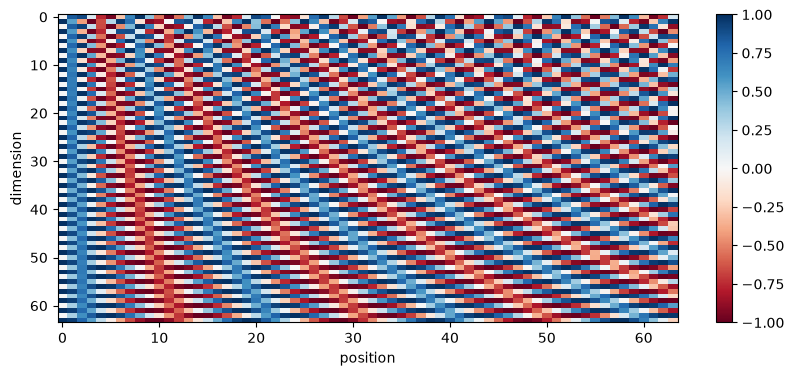

In [2]:
import torch
import matplotlib.pyplot as plt

from transformer.positional_encoding import PositionalEncoding

d_model = 512

pe = PositionalEncoding(d_model, max_len=512)
print(pe.pe.shape)

plt.figure(figsize=(10, 4))
plt.imshow(pe.pe[0, :64, :64].T, cmap="RdBu", aspect="auto")
plt.xlabel("position")
plt.ylabel("dimension")
plt.colorbar()
plt.show()

## Multi-Head Self-Attention

This is the core of the transformer. Every token looks at every other token in the window and asks how much it should pay attention to it.

```
attention = softmax((Q K^T) / sqrt(d_k)) V
```

- **Q, K, V** all come from the same input, which is why it is called *self* attention. One `nn.Linear` produces all three at once (`qkv_proj`).
- **Q K^T** is a `T x T` matrix of scores: how much token `i` cares about token `j`.
- **sqrt(d_k)** keeps the scores from growing with the head size so the softmax does not saturate.
- **softmax** turns the scores into weights that sum to 1, and those weights mix the values **V**.

**Multi-head** means the embedding is split into `num_heads` chunks and the whole thing runs once per chunk in parallel. One head can focus on nearby words, another on grammar, another on meaning. The heads are concatenated and passed through `out_proj`.

The output has the same shape as the input. That is what lets us stack it.

In [3]:
from transformer.mha import MultiHeadSelfAttention

attn = MultiHeadSelfAttention(embed_dim=d_model, num_heads=8)

x = torch.randn(1, 10, d_model)
attn(x).shape

torch.Size([1, 10, 512])

## Feed-Forward

After attention has mixed information between tokens, each token goes through the same small two-layer network on its own. It widens the vector from `embed_dim` to `ff_dim`, applies a ReLU, and squeezes it back to `embed_dim`.

Attention decides *which* tokens to look at. The feed-forward layer decides *what to do* with what it saw.

In [4]:
from transformer.feed_forward import FeedForward

ffn = FeedForward(embed_dim=d_model, ff_dim=2048)
ffn(x).shape

torch.Size([1, 10, 512])

## Encoder Layer

One encoder layer is attention followed by feed-forward, each wrapped in a residual connection with a LayerNorm in front:

```
x = x + attn(norm1(x))
x = x + ffn(norm2(x))
```

The residual (`x + ...`) means every layer only has to learn a small correction to what came in. That is what lets us stack many layers without the gradients vanishing the way they did in RNNs. Input and output have the same shape, so the layer can be repeated as many times as we want.

In [5]:
from transformer.encoder import TransformerEncoderLayer

layer = TransformerEncoderLayer(embed_dim=d_model, num_heads=8, ff_dim=2048)
layer(x).shape

torch.Size([1, 10, 512])

## The Full Model

`TransformerModel` puts it all together:

1. `nn.Embedding` turns each token id into a vector of size `embed_dim`.
2. `PositionalEncoding` adds the position information.
3. A learned `cls_token` is prepended to the sequence. It starts as zeros and, because attention lets it look at every other token, it ends up as a summary of the whole window.
4. `num_layers` encoder layers run in a row.
5. `output_proj` reads only the CLS slot (`x[:, 0]`) and maps it to `output_dim` logits.

This is an **encoder** (the BERT side of the original paper), not a decoder like GPT-2. Nothing stops a token from looking at the tokens after it. That is fine for what we do below: we give the model a window of tokens and ask it to predict the one token that comes next, so `output_dim` is the vocabulary size. It is one prediction per window instead of one per position, but the whole architecture gets trained.

In [6]:
from transformer.model import TransformerModel

demo = TransformerModel(
    vocab_size=1000,
    embed_dim=d_model,
    num_heads=8,
    num_layers=2,
    ff_dim=2048,
    output_dim=1000,
    max_len=64,
)

token_ids = torch.randint(0, 1000, (1, 10))
demo(token_ids).shape

torch.Size([1, 1000])

## Tokenize the Book

The model only understands integers, so the text has to become token ids. We reuse the GPT-2 tokenizer from the other notebooks. Its vocabulary is 50,257 tokens, so that is also the size of our embedding table and our output layer.

The warning about the sequence being longer than 1024 is the tokenizer talking about GPT-2's context window. We only use it to split text, not to run GPT-2, so it can be ignored.

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
ids = tokenizer.encode(text)

print(f"tokens: {len(ids):,}")
print(f"vocab size: {len(tokenizer):,}")
print(ids[:20])
print(tokenizer.decode(ids[:20]))

/home/nick/github-projects/prompting-base-models/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (153199 > 1024). Running this sequence through the model will result in indexing errors


tokens: 153,199
vocab size: 50,257
[1129, 807, 604, 198, 35073, 34026, 198, 68, 14400, 12, 14337, 198, 64, 5337, 198, 20191, 32226, 198, 45, 1268]
19 8 4
nineteen
eighty-four
a novel
George Orwell
NIN


## Building the Training Examples

`NextTokenDataset` in `helpers/data.py` slides a window of `block_size` tokens across the book. Every window is an input `x`, and the one token right after the window is the label `y`. Moving the window by one token gives the next example, so a 153k-token book gives about 153k examples.

In [8]:
from torch.utils.data import DataLoader

from helpers.data import NextTokenDataset

block_size = 64

dataset = NextTokenDataset(ids, block_size=block_size)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

x_window, y_next = dataset[500]
print(f"examples: {len(dataset):,}, batches per epoch: {len(loader):,}")
print("input :", repr(tokenizer.decode(x_window)))
print("target:", repr(tokenizer.decode([y_next])))

examples: 153,135, batches per epoch: 2,393
input : ' propaganda, and wrote that he felt like “an orange that’s\nbeen trodden on by a very dirty boot”. Despite the good salary, he resigned in\nSeptember 1943. In 1944, Orwell ﬁ nished his anti-Stalinist allegory Animal\nFarm. The royalties'
target: ' from'


## Training

`train` in `helpers/train.py` is the plain PyTorch loop: forward pass, cross-entropy between the logits and the true next token, backward pass, AdamW step. It returns the loss at every step so we can plot it.

The model here is small on purpose (about 13M parameters, most of them in the two 50,257 x 128 matrices for the embedding and the output layer). One epoch is about 2,400 steps and takes a couple of minutes on a GTX 1080.

A useful number to keep in mind: with 50,257 possible tokens, guessing uniformly gives a loss of `ln(50257)`, about 10.8. That is where the curve starts. Anything below it means the model has learned something about the book.

parameters: 13,312,721


epoch 1/1: 100%|██████████| 2393/2393 [04:14<00:00,  9.40it/s]


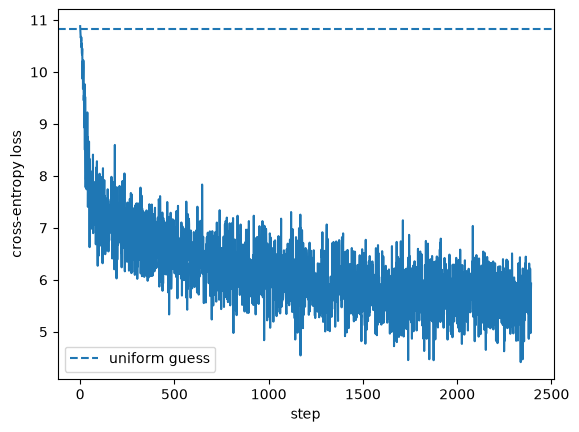

In [9]:
import math

from helpers.train import train

device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransformerModel(
    vocab_size=len(tokenizer),
    embed_dim=128,
    num_heads=4,
    num_layers=2,
    ff_dim=512,
    output_dim=len(tokenizer),
    max_len=block_size,
)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

losses = train(model, loader, epochs=1, lr=3e-4, device=device)

plt.plot(losses)
plt.axhline(math.log(len(tokenizer)), linestyle="--", label="uniform guess")
plt.xlabel("step")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.show()

## Generating Text

`generate` in `helpers/train.py` runs the model in a loop: feed the last `block_size` tokens, turn the logits into probabilities with a softmax, sample one token from them, append it, repeat. Sampling is used instead of always taking the most likely token because a model this small and this undertrained will otherwise lock onto one common token and repeat it forever.

Expect word soup. One epoch on a single book with a 2-layer encoder is nowhere near enough for grammar, but you should see the book's vocabulary show up: names like Winston, words like comrade, Party, telescreen. That is the whole architecture, written from scratch, learning from data.

In [10]:
from helpers.train import generate

torch.manual_seed(0)

prompts = text[:100]

for prompt in prompts:
    print(generate(model, tokenizer, prompt, max_new_tokens=40, block_size=block_size, device=device))
    print("-" * 40)

1 sub bang. sun voice pad
beeny MDMA buildingthink barrencar videogCorrectionlesslyan together transferring feetcer Kru beauty hallunoway mar xously masters dateview Bill corner.gran. parts records
----------------------------------------
9 r Antieen spite Winston of darkper
 intrig folded feeling theary. comrade work two� one hair human Eurasoves deathness his...

 a princess cultivated of kill be offensive-
----------------------------------------
  painful steep entire whispered, not
Dashrate three bombsbehindcomm town herselfaddle ab O av s therefore Here 1912 once special half� existed135 solely while hisounded existed the closedwise. judgeched
----------------------------------------
8-Brienot gramourage he pushed
 lie clean phrase succeededcent degrees of door to. love Tomventh
 much chamber white millions interlect to yielding accepted we minuteing with bear 101 forothes wh
----------------------------------------
  mother starvation to; in
 helpoydcon com col serve pay testimo